### ListOps with S4


In [7]:
from __future__ import annotations
from typing import Dict, Any

from pathlib import Path

from listops_task import ListOpsTask
from src.train_utils.trainer import Trainer

### Configuration


In [8]:
from src.utils.common import device_auto
from src.utils.block_factory import make_s4_block_cfg_ctor

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "LRA" / "listOps")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "max_length": 512,
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/listops_s4_task",
    "warmup_epochs": 5,
    "patience": 10,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 4,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",

    # S4 specific
    "d_state": 64,
    "channels": 1,
    "bidirectional": True,

    # ListOps specific
    "max_length": 512,
}

# Create S4 block configuration
args["block_cfg_ctor"] = make_s4_block_cfg_ctor(**args)

args = device_auto(args)

Using MPS


### Training


In [9]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = ListOpsTask()

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

### Visualization

Load the best checkpoint and visualize the training history.

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 41
Val metrics: {'loss': 1.4726728649139404, 'time_s': 3.7877927090012236, 'acc': 0.4334999995231628}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


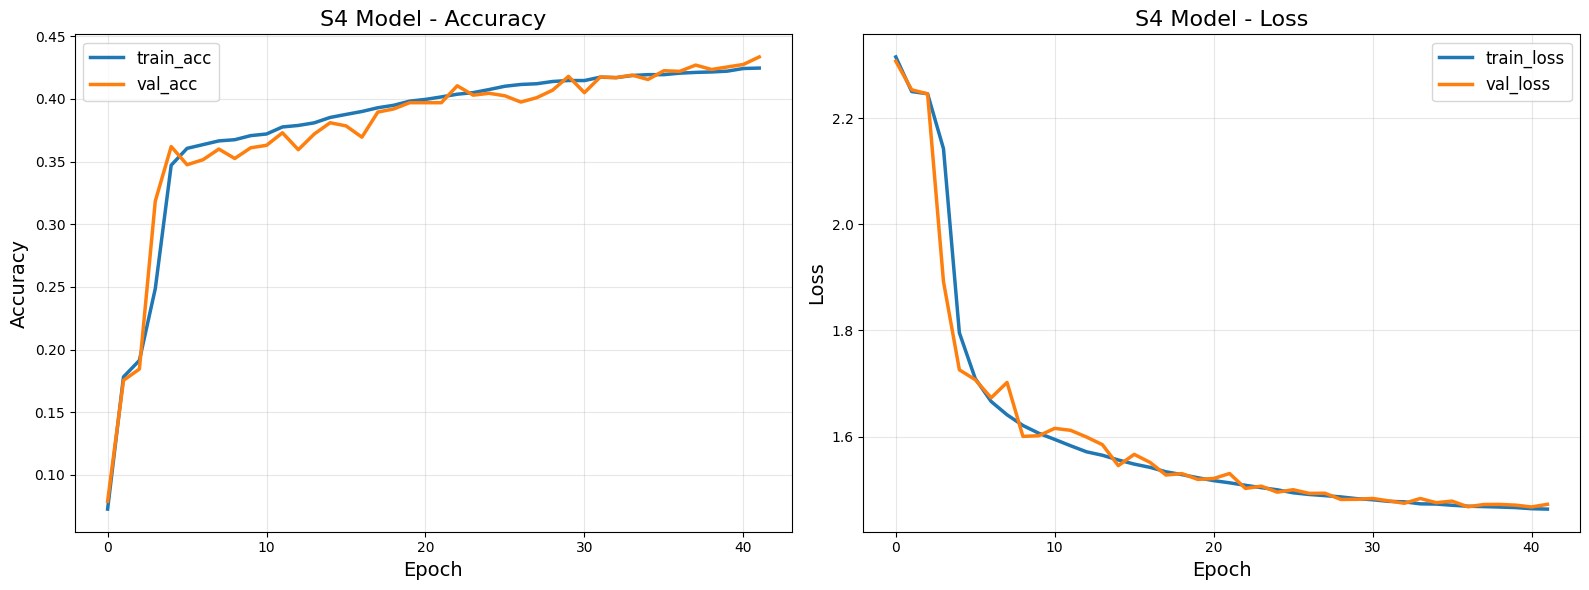


                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: S4CoreAdapter
Number of Blocks: 4

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:                667,786
Trainable parameters:            667,786
Non-trainable parameters:              0
Model size (MB):                    2.55

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
----------------------------------------------------------------------
embedding                      Embedding                           3,200
blocks                         ModuleList 

In [10]:
from src.utils.common import print_model_details
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=ListOpsTask(),
)

history = trainer.history

plot_history(history, model_name="S4")

print_model_details(model=trainer.model)

### Evaluation

After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 41
Val metrics: {'loss': 1.4726728649139404, 'time_s': 3.7877927090012236, 'acc': 0.4334999995231628}
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

 Test results saved to: runs/listops_s4_task/test_results.json

TEST SET RESULTS
   Accuracy: 0.4235 (42.35%)
   Loss: 1.4728
Overall accuracy: 0.4235
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_0                   : 0.848
02. class_9                   : 0.803
03. class_4                   : 0.280
04. class_1                   : 0.268
05. class_8                   : 0.204
06. class_6                   

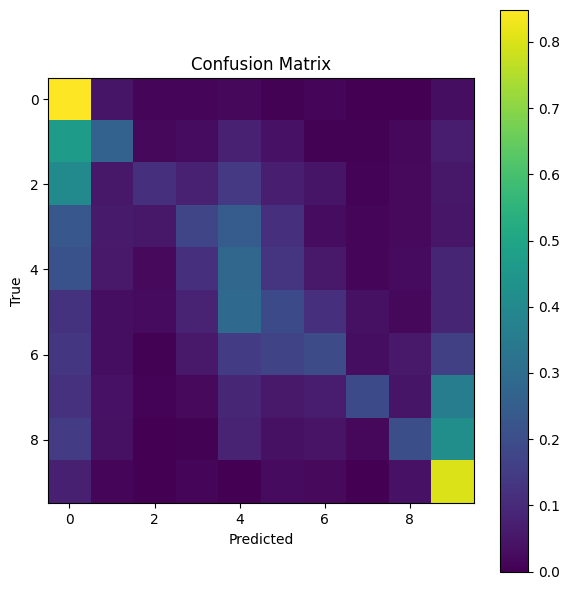

In [6]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=ListOpsTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

### Training with Different Dataset Fractions

This cell demonstrates training with different fractions of the training data
to see how model performance scales with dataset size.

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/listops_s4_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=ListOpsTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history
    plot_history(history, model_name="S4")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=ListOpsTask(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )